In [33]:
# Initialize Otter
import otter
grader = otter.Notebook("hw1-task2.ipynb")

# Homework 1 Task 2: Simple Linear Regression 
## Do eDNA and Traditional Sampling Detect the Same Number of Fish Species?


---

### Background

Environmental DNA (eDNA) sampling detects species by collecting and sequencing genetic material shed into the water — no nets or electrofishing required. Traditional methods require direct capture or observation. This dataset, the same as used in Task 1, compiles results from **68 freshwater lake surveys** across multiple published studies, comparing species detected by each method.

Your goal is to investigate whether **eDNA-based species richness** (`dna_richness`) can predict **traditional species richness** (`trad_richness`) — the number of species found by conventional gear. This is a question for conservation monitoring: if the two methods broadly agree, eDNA could replace expensive field surveys.

You will build and evaluate a simple linear regression model from scratch using NumPy, and then verify your results with `sklearn` and `statsmodels`.

---


The dataset has the following key columns:

| Column | Description |
|---|---|
| `author` | First author of the primary study |
| `area_ha` | Lake area (hectares) |
| `dna_richness` | Number of fish species detected by eDNA |
| `trad_richness` | Number of fish species detected by conventional surveys |
| `dna_only` | Number of species found **only** by eDNA |
| `trad_only` | Number of species found **only** by conventional surveys |
| `shared` | Number of species found by **both** methods |
| `union` | Total unique species (`dna_only + trad_only + shared`) |
| `marker_cat` | Whether single or multiple genetic markers were used (single vs. multiple eDNA markers) |
| `gear_cat` | Whether single or multiple conventional survey gear types were used (single vs. multiple) |
| `total_vol_liter` | Total volume of water sampled (litres) |

### Setup: Load libraries and read in data


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('lakes_data.csv') 
df.head()

,author,year_pub,area_ha,dna_richness,trad_richness,dna_only,trad_only,shared,union,marker_count,locus,marker_cat,gear_cat,match_effort,field_reps,rep_vol_liter,total_vol_liter
0,Civade,2016,545.0,14,18,1,5,13,19,1,12s,single,single,yes,3,45.00,135.00
1,Doble,2020,3290000.0,92,62,41,11,51,103,4,12s_16s,multiple,single,yes,21,10.00,210.00
2,Evans,2017,2.0,15,10,5,0,10,15,3,12s_16s_cytb,multiple,multiple,yes,31,0.25,7.75
3,Fujii,2019,9.0,0,7,0,7,0,7,1,12s,single,multiple,no,1,1.00,1.00
4,Fujii,2019,5.0,2,8,0,6,2,8,1,12s,single,multiple,no,1,1.00,1.00


<!-- BEGIN QUESTION -->

---
## Step 1: Visualise the Relationship

Create an exploratory data visualization exploring the relationship between `dna_richness` and `trad_richness`. 

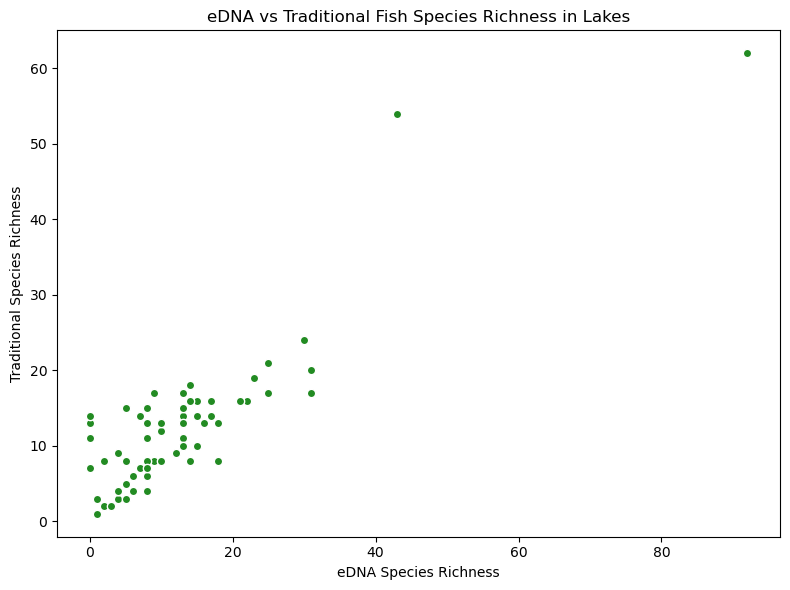

In [35]:
# Create scatter plot to explore the relationship between dna_richness and trad_richness
plt.figure(figsize=(8, 6))
plt.scatter(df["dna_richness"], df["trad_richness"],
            color="forestgreen", edgecolors="white")

# Add axis labels and title
plt.xlabel("eDNA Species Richness")
plt.ylabel("Traditional Species Richness")
plt.title("eDNA vs Traditional Fish Species Richness in Lakes")
plt.tight_layout()
plt.show()


> **Q1:** Does there appear to be a relationship between the two variables? Describe the direction, form, and approximate strength.

Yes, there appears to be a relationship between `dna_richness` and `trad_richness`. The direction is positive, meaning as eDNA species richness increases, traditional species richness also tends to increase. The form appears to be linear, as the relationship follows a roughly straight-line pattern across the range of observed values. The strength appears moderate to strong, as most points follow the trend closely, though there are a few outliers pulling the trend.

<!-- END QUESTION -->

---
## Step 2: Fit the Regression 

Use `numpy` and the formula below to manually calculate β₁ and β₀. Store your coefficients in the `beta_1` and `beta_0` variables. Then, create a scatter plot of `trad_richness` and `dna_richness` (likely similar to the plot you created above!). Add the fitted line to the scatter plot, and the equation of the line as a legend item. 

$$\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

β₁     = 0.6519
β₀     = 4.0013


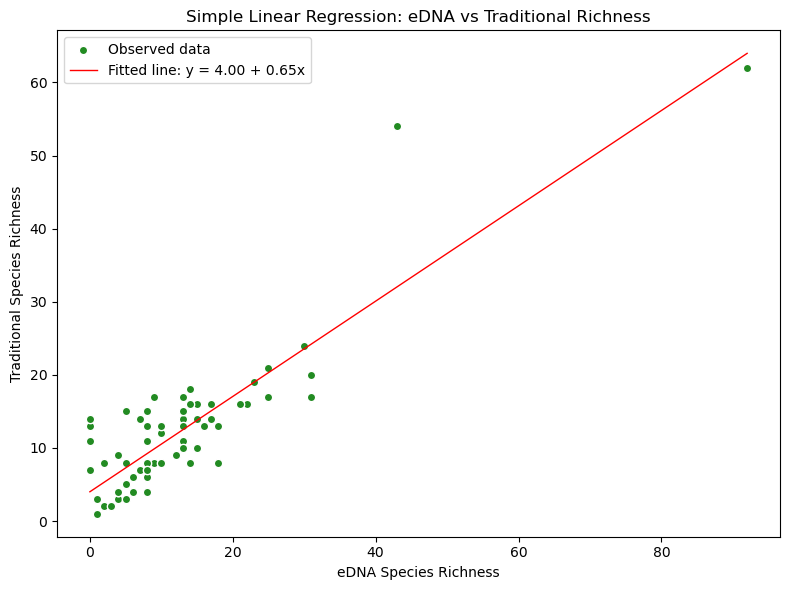

In [36]:
# Extract predictor (x) and response (y) as numpy arrays
x = df["dna_richness"].values
y = df["trad_richness"].values

# Compute the mean of x and y
x_mean = np.mean(x)
y_mean = np.mean(y)

# Calculate slope (beta_1) using the OLS formula: covariance / variance of x
beta_1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)

# Calculate intercept (beta_0) so the line passes through the point (x_mean, y_mean)
beta_0 = y_mean - beta_1 * x_mean

print(f"\u03b2\u2081     = {beta_1:.4f}")
print(f"\u03b2\u2080     = {beta_0:.4f}")

# Generate x values for plotting the regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = beta_0 + beta_1 * x_line

# Plot scatter with fitted line and line equation in the legend
plt.figure(figsize = (8, 6))
plt.scatter(x, y, color="forestgreen", edgecolors="white", label="Observed data")
plt.plot(x_line, y_line, color="red", linewidth=1,
         label=f"Fitted line: y = {beta_0:.2f} + {beta_1:.2f}x")
plt.xlabel("eDNA Species Richness")
plt.ylabel("Traditional Species Richness")
plt.title("Simple Linear Regression: eDNA vs Traditional Richness")
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

---
## Step 3: Interpret the Coefficients



**Q2:** Interpret the slope in plain language. Include units.



**Q3:** Interpret the intercept. Is it ecologically meaningful?



**Q2 Answer:** The slope is 0.6519, meaning that for every one additional fish species detected by eDNA, traditional surveys are expected to detect about 0.65 more species. Both variables are measured in number of species, so the slope is in units of traditional species per eDNA species.

**Q3 Answer:** The intercept is 4.0013. It means that when eDNA detects zero species, the model still predicts traditional surveys would find about 4 species. This does not have much ecological significance, since a lake with zero eDNA detections is rarely found. The intercept is mainly just a starting point for the regression line rather than a meaningful biological finding.

<!-- END QUESTION -->

---
## Step 4: Compute Standard Errors

Use `numpy` and the formula below to manually calculate the standard errors. Store the RSE in a variable called `RSE`, the standard error of β₁ in a variable called `SE_beta_1`, and the standard error of β₀ in a variable called `SE_beta_0`. 

$$SS_{xx} = \sum(x_i - \bar{x})^2$$

$$RSE = \sqrt{\frac{RSS}{n-2}}$$

$$SE(\hat{\beta}_1) = \frac{RSE}{SS_{xx}}$$

$$SE(\hat{\beta}_0) = RSE \sqrt{\frac{1}{n} + \frac{\bar{x}^2}{SS_{xx}}}$$

In [38]:
# Compute fitted values and residuals from the regression line
y_pred = beta_0 + beta_1 * x
residuals = y - y_pred

# RSS is the total squared error; SS_xx is the variance in x (needed for SE formulas)
n  = len(x)
RSS = np.sum(residuals**2)
SS_xx = np.sum((x - x_mean)**2)

# RSE is the average prediction error in units of species (degrees of freedom = n - 2)
RSE = np.sqrt(RSS / (n - 2))

# Compute standard error for beta_1 and beta_0
SE_beta_1 = RSE / np.sqrt(SS_xx)
SE_beta_0 = RSE * np.sqrt(1/n + x_mean**2 / SS_xx)

print(f"RSE = {RSE:.4f} (species)")
print(f"SE(\u03b2\u2081) = {SE_beta_1:.4f}")
print(f"SE(\u03b2\u2080) = {SE_beta_0:.4f}")


RSE = 4.7441 (species)
SE(β₁) = 0.0446
SE(β₀) = 0.7974


In [39]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 5: Manually Calculate 95% Confidence Intervals for $\beta_0$ and $\beta_1$

Using the formula below, manually calculate an approximate 95% confidence interval for β₀ and β₁. 

$$95\% \text{ CI} \simeq \hat{\beta}_i \pm 2 \times SE(\hat{\beta})$$

In [40]:
# Compute 95% CI for the slope using beta_1 ± 2 * SE(beta_1)
CI_beta_1_lower = beta_1 - 2 * SE_beta_1
CI_beta_1_upper = beta_1 + 2 * SE_beta_1

# Compute 95% CI for the intercept: beta_0 ± 2 * SE(beta_0)
CI_beta_0_lower = beta_0 - 2 * SE_beta_0
CI_beta_0_upper = beta_0 + 2 * SE_beta_0

print(f"\n95% CI for \u03b2\u2081 (slope): ({CI_beta_1_lower:.4f},  {CI_beta_1_upper:.4f})")
print(f"95% CI for \u03b2\u2080 (intercept): ({CI_beta_0_lower:.4f},  {CI_beta_0_upper:.4f})")


95% CI for β₁ (slope): (0.5627,  0.7411)
95% CI for β₀ (intercept): (2.4064,  5.5962)


In [41]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Interpret the 95% CI for the slope in plain language.

The 95% confidence interval for the slope is (0.5627, 0.7411). This means we are 95% confident that the true slope is between 0.56 and 0.74. In other words, for every additional species detected by eDNA, traditional surveys are expected to detect between 0.56 and 0.74 more species. Since the interval does not include zero, we can conclude that there is positive relationship between eDNA richness and traditional richness.

<!-- END QUESTION -->

---
## Step 6: Assess Model Accuracy — R²

Manually calculate the R² using the formula below. Store your answer in the `R2` variable. 

$$R^2 = 1 - \frac{RSS}{TSS} \qquad TSS = \sum_{i=1}^{n}(y_i - \bar{y})^2$$

In [42]:
# Compute TSS and R²
TSS = np.sum((y - y_mean)**2)
R2 = 1 - RSS / TSS

print(f"R\u00b2     = {R2:.4f}")

R²     = 0.7640


In [43]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Interpret the R² in the context of this problem.

The R² value is 0.7640. This means eDNA richness explains about 76.4% of the variation in traditional species richness. This suggests that the two methods agree and that eDNA is a good predictor of traditional richness. The remaining 23.6% is unexplained, likely due to differences in sampling effort, lake size, or survey methods across the 68 lakes.

<!-- END QUESTION -->

---
## Step 7: Verify with `sklearn`

Let's confirm our manual OLS results using `sklearn`'s `LinearRegression`.

> **Note:** `sklearn` expects a 2D feature matrix, so we need to reshape `X` from
> shape `(n,)` to `(n, 1)` using `.reshape(-1, 1)` before fitting.

1. **Fit the model** — `LinearRegression().fit(X_2d, Y)` finds the same OLS solution as
   our manual β₁ and β₀ formulas.
2. **Extract coefficients** — `.coef_[0]` is the slope, `.intercept_` is the intercept.
3. **Compute R²** — `r2_score(Y, y_pred)` uses the $R^2 = 1 - RSS/TSS$. formula, where `y_pred = your_fitted_model.predict(X_2d)`
   
4. Create a table that compares the manually calculated and `LinearRegression()` generated slope, intercept, and R². 

If your manual calculations are correct, all three values should match `sklearn`'s output
to at least four decimal places. Any discrepancy beyond floating-point rounding
indicates a bug in your manual formulas.

In [44]:
# Reshape x to 2D array since sklearn expects input shape (n_samples, n_features)
X_2d = x.reshape(-1, 1)

# Fit linear regression model using sklearn
sk_model = LinearRegression().fit(X_2d, y)

# Extract slope, intercept and R² from the fitted model
sk_slope = sk_model.coef_[0]
sk_intercept = sk_model.intercept_
sk_r2 = r2_score(y, sk_model.predict(X_2d))

print(f"sklearn slope = {sk_slope:.4f}, manual slope = {beta_1:.4f}")
print(f"sklearn intercept = {sk_intercept:.4f}, manual intercept = {beta_0:.4f}")
print(f"sklearn R\u00b2 = {sk_r2:.4f}, manual R\u00b2 = {R2:.4f}")

# Compare manual and sklearn results in a table
comparison = pd.DataFrame({
    "Method":    ["Manual (NumPy)", "sklearn"],
    "Slope":     [round(beta_1, 4), round(sk_slope, 4)],
    "Intercept": [round(beta_0, 4), round(sk_intercept, 4)],
    "R²":        [round(R2, 4), round(sk_r2, 4)]
})
comparison

sklearn slope = 0.6519, manual slope = 0.6519
sklearn intercept = 4.0013, manual intercept = 4.0013
sklearn R² = 0.7640, manual R² = 0.7640


,Method,Slope,Intercept,R²
0,Manual (NumPy),0.6519,4.0013,0.764
1,sklearn,0.6519,4.0013,0.764


In [45]:
grader.check("q9")

q9 results: All test cases passed!

---
## Step 8: Verify with `statsmodels` 

`sklearn` is optimized for **prediction**: it fits models efficiently and scores them, but it deliberately leaves out statistical inference (standard errors, p-values, confidence intervals).

`statsmodels` is designed for **inference**: it fits the same OLS model but reports the full regression table — coefficients, standard errors, t-statistics, p-values, and confidence intervals — matching what you'd see in a statistics textbook.


1. Import `statsmodels.api as sm`.
2. Add a constant (intercept) column to `X` using `sm.add_constant()`.
3. Fit the model with `sm.OLS(Y, X_sm).fit()` and call `.summary()` to display the full regression table.
4. Extract the slope, intercept, and R² from the fitted model and compare them to your numpy and sklearn results. Store the statsmodels slope in `sm_slope`, the intercept in `sm_intercept`, and R² in `sm_r2`.

If all three methods are correct, the coefficients and R² should match to at least four decimal places.

In [46]:
# Import statsmodels for statistical inference
import statsmodels.api as sm

# Add a constant to x so the model includes an intercept
X_sm = sm.add_constant(x)

# Fit OLS model and display the full regression summary
sm_model = sm.OLS(y, X_sm).fit()
print(sm_model.summary())

# Extract intercept, slope, and R² from the fitted model
sm_intercept = sm_model.params[0]
sm_slope     = sm_model.params[1]
sm_r2        = sm_model.rsquared

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     213.7
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           2.25e-22
Time:                        22:51:22   Log-Likelihood:                -201.34
No. Observations:                  68   AIC:                             406.7
Df Residuals:                      66   BIC:                             411.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0013      0.797      5.018      0.0

In [47]:
grader.check("q10")

q10 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Look at the **p-values** for the slope (`dna_richness`) and intercept (`const`) in the statsmodels summary.
>
> - What does the p-value for the **slope** tell you? Is the relationship between eDNA richness and traditional richness statistically significant? How do you know?


The p-value for the slope is 0.000, which is well below the 0.05 threshold. This means the relationship between eDNA richness and traditional richness is statistically significant. In other words, it is very unlikely that this result happened by chance, so we can conclude that eDNA richness is a real and meaningful predictor of traditional richness. The p-value for the intercept is also 0.000, meaning the intercept is also statistically significant.

<!-- END QUESTION -->



---

**Run the cell below to receive credit for all auto graded questions.**

In [48]:
grader.check_all()

q10 results: All test cases passed!

q2 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!